In [8]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

# Load dataset
df = pd.read_csv("sales_data_with_discounts.csv")

# Show first 5 rows
df.head()

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [9]:
# Check data types and structure
df.info()

# Check missing values in each column
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               450 non-null    object 
 1   Day                450 non-null    object 
 2   SKU                450 non-null    object 
 3   City               450 non-null    object 
 4   Volume             450 non-null    int64  
 5   BU                 450 non-null    object 
 6   Brand              450 non-null    object 
 7   Model              450 non-null    object 
 8   Avg Price          450 non-null    int64  
 9   Total Sales Value  450 non-null    int64  
 10  Discount Rate (%)  450 non-null    float64
 11  Discount Amount    450 non-null    float64
 12  Net Sales Value    450 non-null    float64
dtypes: float64(3), int64(3), object(7)
memory usage: 45.8+ KB


Date                 0
Day                  0
SKU                  0
City                 0
Volume               0
BU                   0
Brand                0
Model                0
Avg Price            0
Total Sales Value    0
Discount Rate (%)    0
Discount Amount      0
Net Sales Value      0
dtype: int64

In [10]:
# Select only numerical columns
num = df.select_dtypes(include=np.number)

# Calculate basic statistics
num.mean()          # Average value
num.median()        # Middle value
num.mode().iloc[0]  # Most frequent value
num.std()           # Data spread (variation)

Volume                   4.231602
Avg Price            18079.904840
Total Sales Value    50535.074173
Discount Rate (%)        4.220602
Discount Amount       4509.902963
Net Sales Value      46358.656624
dtype: float64

### Interpretation of Descriptive Statistics
* **Central Tendency:** The Mean and Median values provide the average and typical middle-point for sales and discounts. A noticeable difference between the Mean and Median (especially if Mean > Median) suggests that our data is positively skewed.
* **Dispersion (Spread):** The Standard Deviation indicates how spread out the data points are. A high standard deviation in 'Total Sales Value' implies highly variable transaction sizes, ranging from very small to exceptionally large purchases.

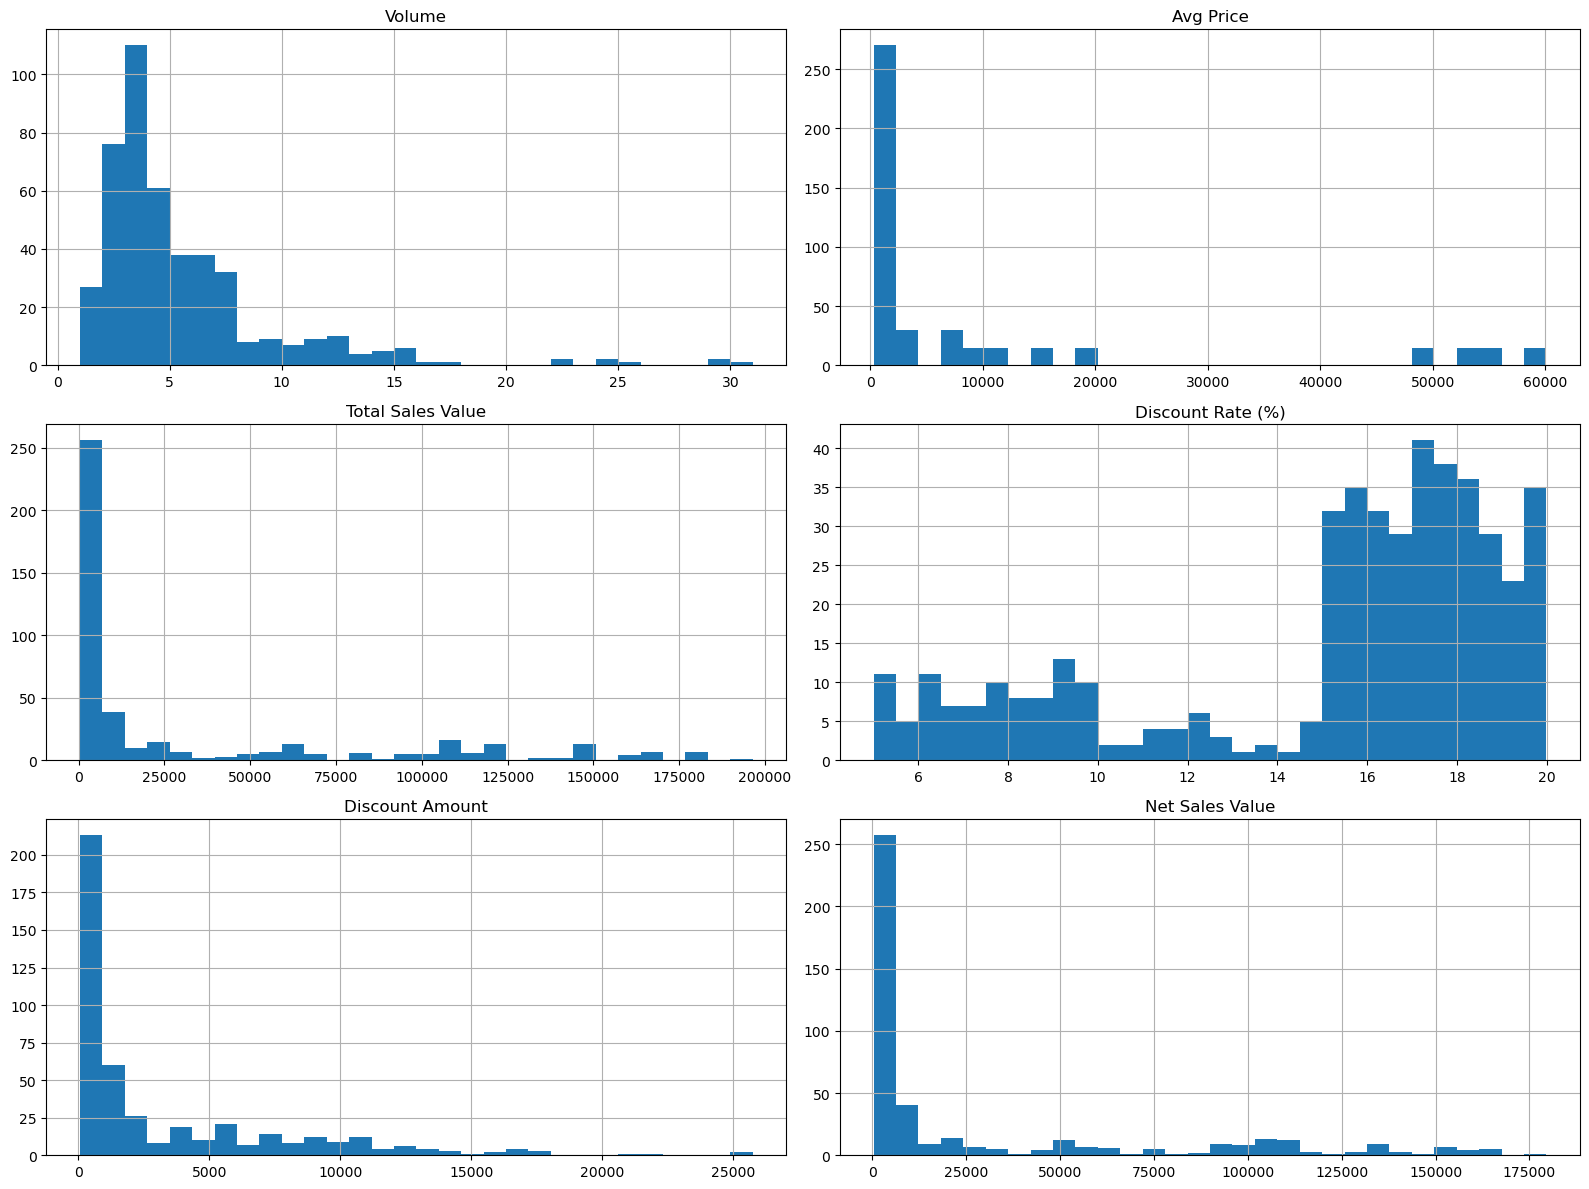

In [11]:
# Plot histogram for numerical data
num.hist(figsize=(16,12), bins=30)

# Automatically adjust spacing between plots
plt.tight_layout()

# Display graph
plt.show()

### Inferences from Histograms (Distribution Analysis)
* **Skewness:** Most numerical variables, such as 'Volume' and 'Total Sales Value', exhibit a **right-skewed (positive) distribution**. 
* **Business Insight:** This indicates that the majority of the transactions involve smaller ticket sizes or lower volumes, while there is a long tail of rare, high-value transactions.

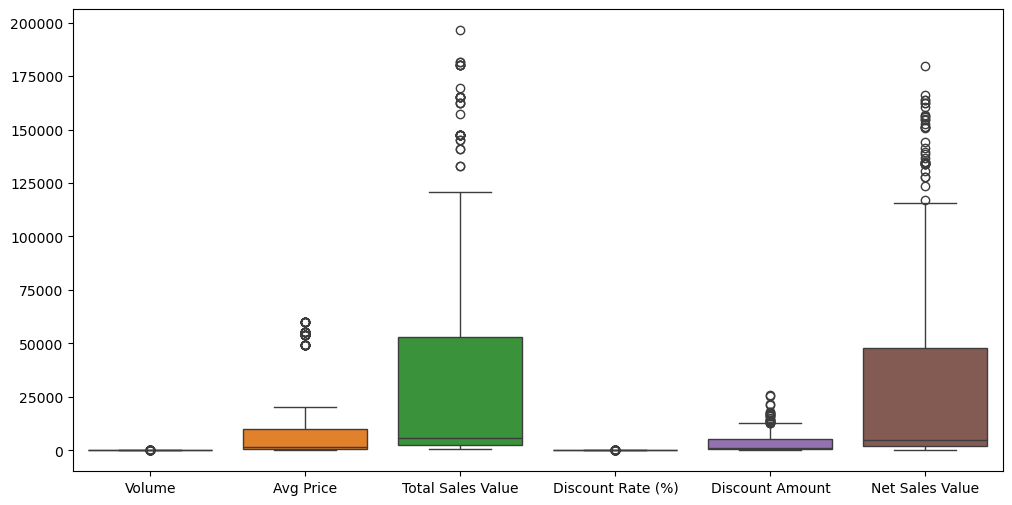

In [12]:
# Boxplot to detect outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=num)

# Display graph
plt.show()

### Inferences from Box Plots (Outlier Detection)
* **Presence of Outliers:** The box plots clearly highlight several data points above the upper whisker for variables like 'Total Sales Value', 'Avg Price', and 'Discount Amount'.
* **Business Insight:** These extreme values are likely not data errors but represent premium product sales, VIP customers, or B2B bulk deals. Understanding these outliers is crucial for revenue maximization.

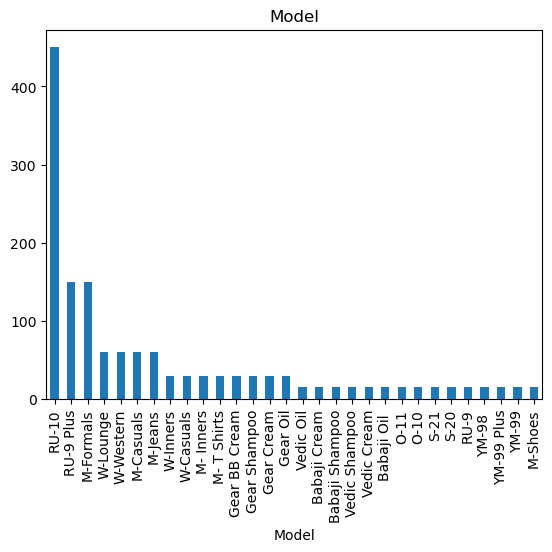

In [13]:
# Select categorical columns
cat = df.select_dtypes(include='object')

# Plot bar chart for each category
for col in cat.columns:
    df[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.show

### Insights from Categorical Distributions
* **Category Dominance:** The bar charts allow us to identify the most frequent categories. For instance, we can easily spot the 'City' generating the highest footfall or the 'Brand' with the maximum number of transactions.
* **Volume Drivers:** Analyzing these distributions helps in identifying which specific Business Units (BUs) or Models are driving the daily business operations.

## Final Conclusion & Business Summary
1. **Data Distribution:** The sales and volume metrics are heavily right-skewed, highlighting that standard, smaller transactions form the backbone of the business volume.
2. **Impact of Outliers:** High-value transactions exist as outliers. While few in number, they likely contribute significantly to the overall Net Sales Value.
3. **Strategic Value:** By analyzing categorical frequencies, the business can optimize its inventory for top-performing brands and cities. Furthermore, studying the discount distributions can help in crafting better, targeted promotional campaigns to convert low-volume days into high-volume ones.